# Weather Data Analysis

## 1. Importing Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from holoviews.examples.gallery.demos.bokeh.us_unemployment import colors

## 2. Load Dataset

In [5]:
df = pd.read_csv('weatherHistory.csv')
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)
df.rename(columns={'Formatted Date': 'Datetime'}, inplace=True)
df['Year']  = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Hour']  = df['Datetime'].dt.hour
df


,Datetime,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,Year,Month,Hour
0,2006-03-31 22:00:00+00:00,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251,15.8263,0,1015.13,Partly cloudy throughout the day.,2006,3,22
1,2006-03-31 23:00:00+00:00,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259,15.8263,0,1015.63,Partly cloudy throughout the day.,2006,3,23
2,2006-04-01 00:00:00+00:00,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204,14.9569,0,1015.94,Partly cloudy throughout the day.,2006,4,0
3,2006-04-01 01:00:00+00:00,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269,15.8263,0,1016.41,Partly cloudy throughout the day.,2006,4,1
4,2006-04-01 02:00:00+00:00,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259,15.8263,0,1016.51,Partly cloudy throughout the day.,2006,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 17:00:00+00:00,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31,16.1000,0,1014.36,Partly cloudy starting in the morning.,2016,9,17
96449,2016-09-09 18:00:00+00:00,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20,15.5526,0,1015.16,Partly cloudy starting in the morning.,2016,9,18
96450,2016-09-09 19:00:00+00:00,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30,16.1000,0,1015.66,Partly cloudy starting in the morning.,2016,9,19
96451,2016-09-09 20:00:00+00:00,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20,16.1000,0,1015.95,Partly cloudy starting in the morning.,2016,9,20


## 3. Dataset Overview

In [6]:
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Missing Value Percentage ===')
print((df.isnull().sum() / len(df) * 100).round(2))

=== Data Types ===
Datetime                    datetime64[ns, UTC]
Summary                                  object
Precip Type                              object
Temperature (C)                         float64
Apparent Temperature (C)                float64
Humidity                                float64
Wind Speed (km/h)                       float64
Wind Bearing (degrees)                    int64
Visibility (km)                         float64
Loud Cover                                int64
Pressure (millibars)                    float64
Daily Summary                            object
Year                                      int32
Month                                     int32
Hour                                      int32
dtype: object

=== Missing Values ===
Datetime                      0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0

## 4. Dataset Description

In [7]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Year,Month,Hour
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000,96453.00000,96453.000000,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956,2011.00029,6.523001,11.499891
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906,3.16216,3.448501,6.922049
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,2005.00000,1.000000,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000,2008.00000,4.000000,6.000000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000,2011.00000,7.000000,11.000000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000,2014.00000,10.000000,17.000000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000,2016.00000,12.000000,23.000000


## 5. Data Cleaning

In [8]:
df['Precip Type'] = df['Precip Type'].fillna('none')
print('Unique values in Loud Cover:', df['Loud Cover'].unique())
df.drop(columns=['Loud Cover'], inplace=True)
print('Rows with Pressure == 0:', (df['Pressure (millibars)'] == 0).sum())
df = df[df['Pressure (millibars)'] > 0]
print(f'\nCleaned dataset shape: {df.shape}')

Unique values in Loud Cover: [0]
Rows with Pressure == 0: 1288

Cleaned dataset shape: (95165, 14)


## 6. Analysis

### 6.1 Distribution of Numerical Features

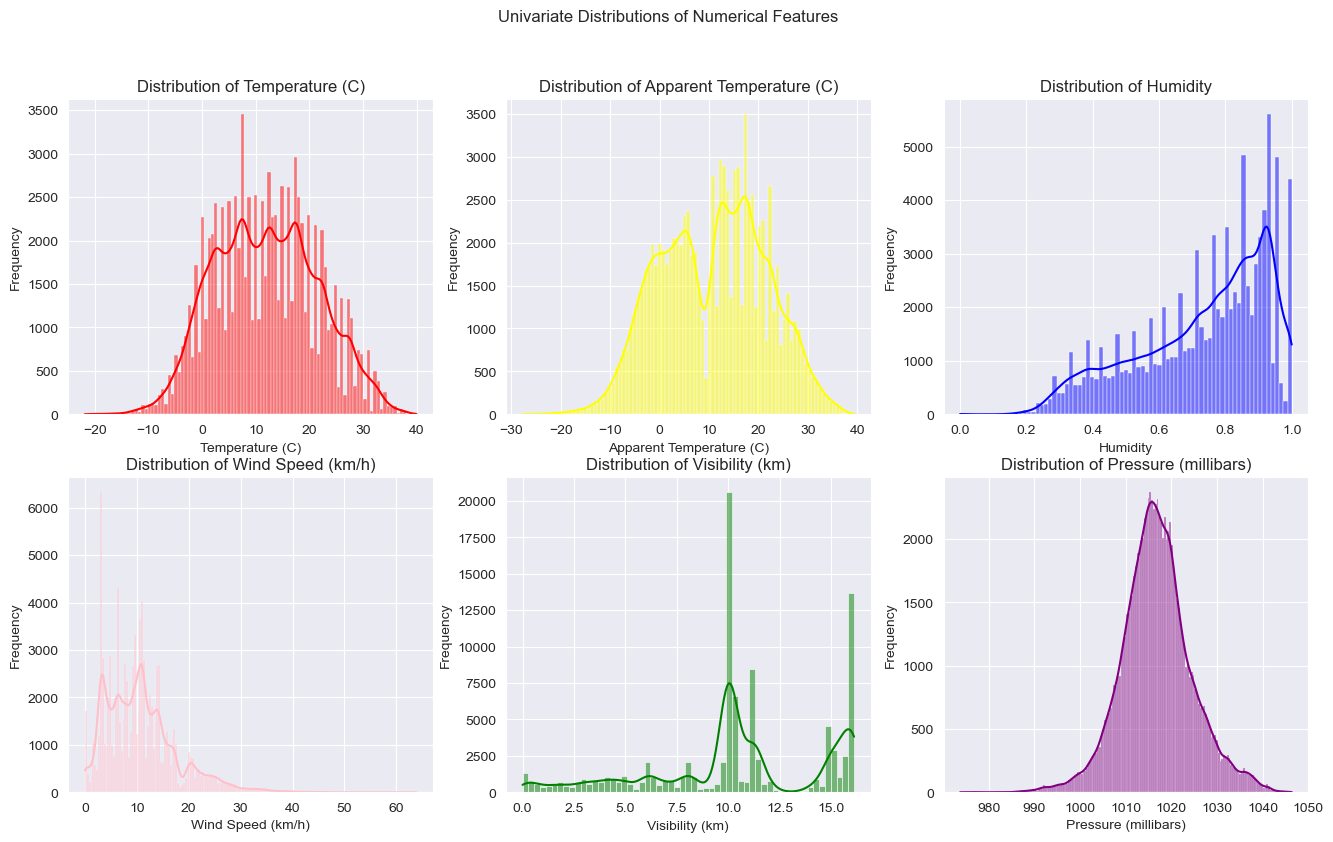

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()


sns.histplot(df['Temperature (C)'], kde=True, ax=axes[0], color='red')
axes[0].set_title('Distribution of Temperature (C)')
axes[0].set_xlabel('Temperature (C)'); axes[0].set_ylabel('Frequency')

sns.histplot(df['Apparent Temperature (C)'], kde=True, ax=axes[1], color='yellow')
axes[1].set_title('Distribution of Apparent Temperature (C)')
axes[1].set_xlabel('Apparent Temperature (C)'); axes[1].set_ylabel('Frequency')

sns.histplot(df['Humidity'], kde=True, ax=axes[2], color='blue')
axes[2].set_title('Distribution of Humidity')
axes[2].set_xlabel('Humidity'); axes[2].set_ylabel('Frequency')

sns.histplot(df['Wind Speed (km/h)'], kde=True, ax=axes[3], color='pink')
axes[3].set_title('Distribution of Wind Speed (km/h)')
axes[3].set_xlabel('Wind Speed (km/h)'); axes[3].set_ylabel('Frequency')

sns.histplot(df['Visibility (km)'], kde=True, ax=axes[4], color='green')
axes[4].set_title('Distribution of Visibility (km)')
axes[4].set_xlabel('Visibility (km)'); axes[4].set_ylabel('Frequency')

sns.histplot(df['Pressure (millibars)'], kde=True, ax=axes[5], color='purple')
axes[5].set_title('Distribution of Pressure (millibars)')
axes[5].set_xlabel('Pressure (millibars)'); axes[5].set_ylabel('Frequency')

plt.suptitle('Univariate Distributions of Numerical Features')
plt.savefig('./visuals/fig1_distributions.png')
plt.show()

### 6.2 Weather Summary — Top 10 Categories

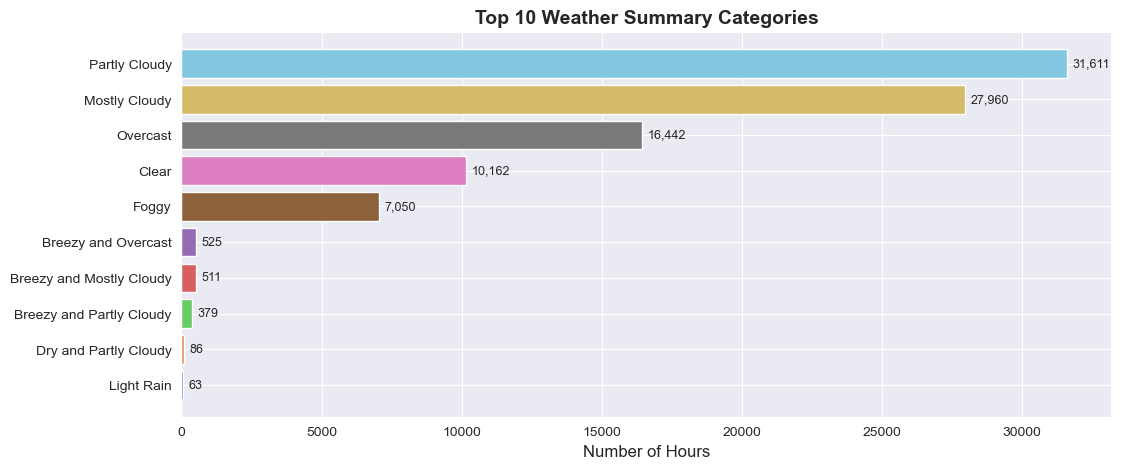

In [14]:
top_summary = df['Summary'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_summary.index[::-1], top_summary.values[::-1],
               color=sns.color_palette('muted', 10))
ax.set_xlabel('Number of Hours', fontsize=12)
ax.set_title('Top 10 Weather Summary Categories', fontsize=14, fontweight='bold')
for bar, val in zip(bars, top_summary.values[::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

plt.savefig('./visuals/fig2_summary_categories.png', bbox_inches='tight')
plt.show()

### 5.3 Precipitation Type Distribution


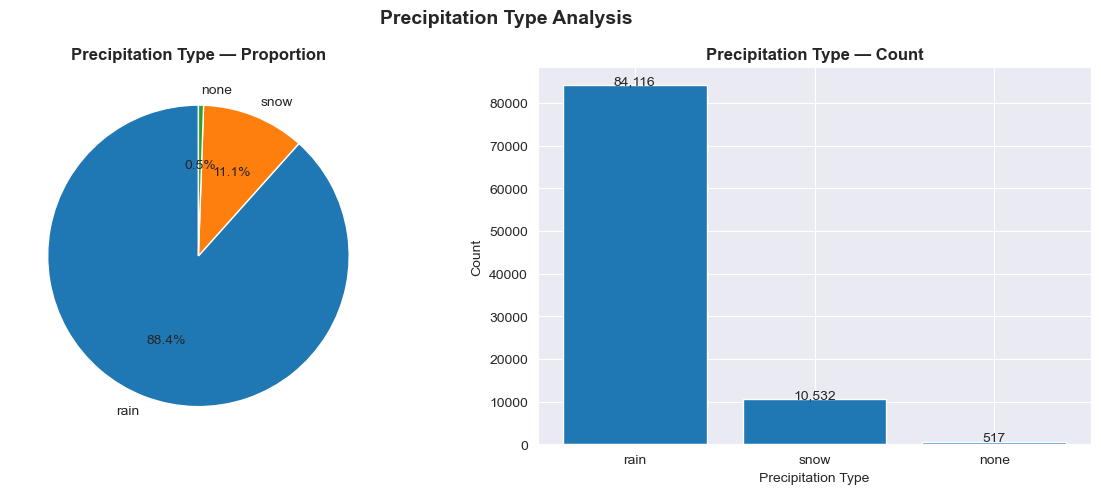

In [15]:
precip_counts = df['Precip Type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(precip_counts, labels=precip_counts.index, autopct='%1.1f%%',
            startangle=90)
axes[0].set_title('Precipitation Type — Proportion', fontsize=12, fontweight='bold')

# Bar chart
axes[1].bar(precip_counts.index, precip_counts.values)
axes[1].set_title('Precipitation Type — Count', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Precipitation Type')
axes[1].set_ylabel('Count')
for i, (idx, val) in enumerate(precip_counts.items()):
    axes[1].text(i, val + 200, f'{val:,}', ha='center', fontsize=10)

plt.suptitle('Precipitation Type Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./visuals/fig3_precip_type.png')
plt.show()

## 6.Bivariate Analysis

### 6.1 Correlation Heatmap

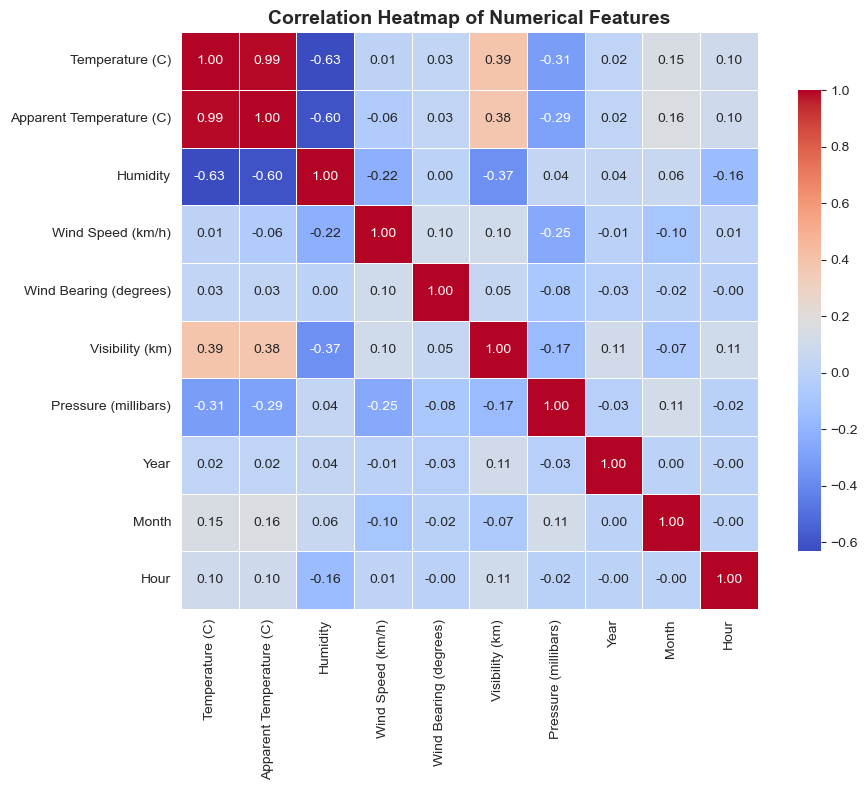

In [18]:
num_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./visuals/fig4_correlation_heatmap.png', bbox_inches='tight')
plt.show()

### 6.2 Temperature and Apparent Temperature

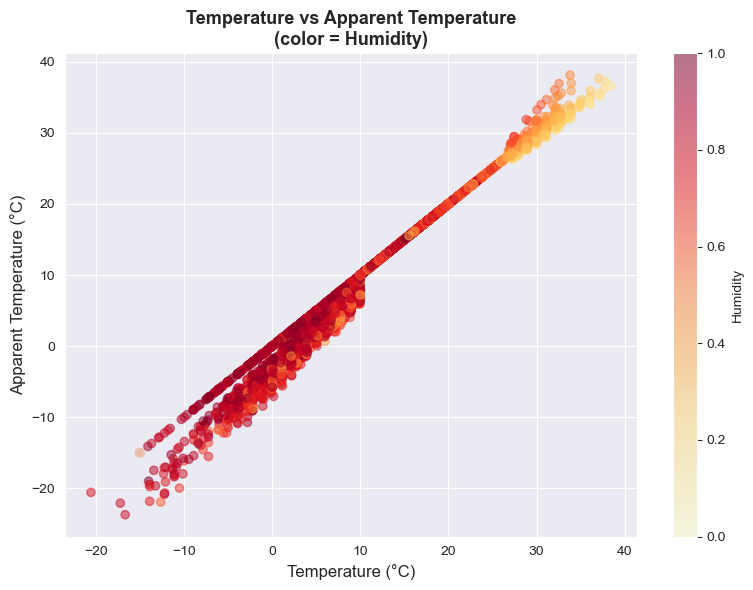

In [21]:
sample = df.sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(sample['Temperature (C)'], sample['Apparent Temperature (C)'],
                c=sample['Humidity'], cmap='YlOrRd', alpha=0.5)
plt.colorbar(sc, ax=ax, label='Humidity')
ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Apparent Temperature (°C)', fontsize=12)
ax.set_title('Temperature vs Apparent Temperature\n(color = Humidity)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('./visuals/fig5_temp_vs_apparent.png', bbox_inches='tight')
plt.show()

### 6.3 Temperature by Precipitation Type

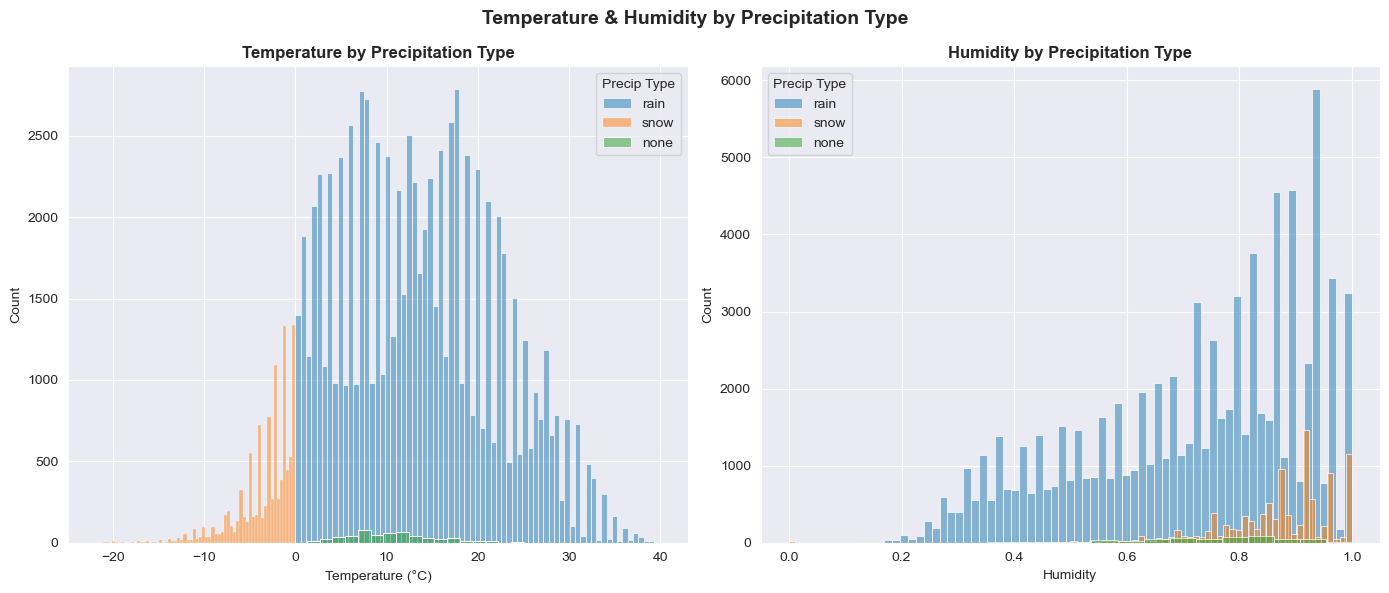

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for precip_type in df['Precip Type'].unique():
    subset = df[df['Precip Type'] == precip_type]
    sns.histplot(subset['Temperature (C)'], ax=axes[0],
                 label=precip_type, alpha=0.5,)

axes[0].set_title('Temperature by Precipitation Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Count')
axes[0].legend(title='Precip Type')

for precip_type in df['Precip Type'].unique():
    subset = df[df['Precip Type'] == precip_type]
    sns.histplot(subset['Humidity'], ax=axes[1],
                 label=precip_type, alpha=0.5, edgecolor='white', linewidth=0.5)

axes[1].set_title('Humidity by Precipitation Type', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Humidity')
axes[1].set_ylabel('Count')
axes[1].legend(title='Precip Type')

plt.suptitle('Temperature & Humidity by Precipitation Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./visuals/fig6_temp_humidity_by_precip.png', bbox_inches='tight')
plt.show()

### 6.4 Wind Speed vs Visibility

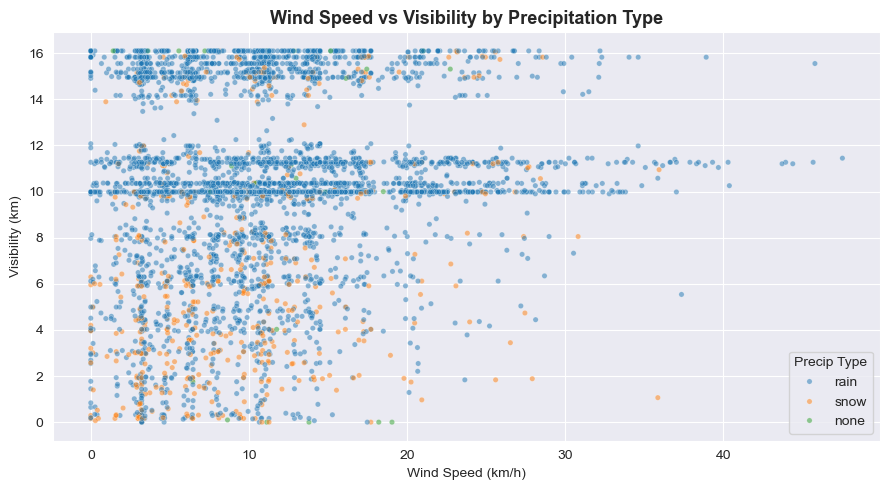

In [106]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=sample, x='Wind Speed (km/h)', y='Visibility (km)',
                hue='Precip Type', alpha=0.5, s=15, ax=ax)
ax.set_title('Wind Speed vs Visibility by Precipitation Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Wind Speed (km/h)')
ax.set_ylabel('Visibility (km)')
ax.legend(title='Precip Type')
plt.tight_layout()
plt.savefig('./visuals/fig7_wind_visibility.png', bbox_inches='tight')
plt.show()

## 7. Temporal Analysis

### 7.1 Monthly Analysis (Humidity, Wind Speed, Pressure, Temperature)

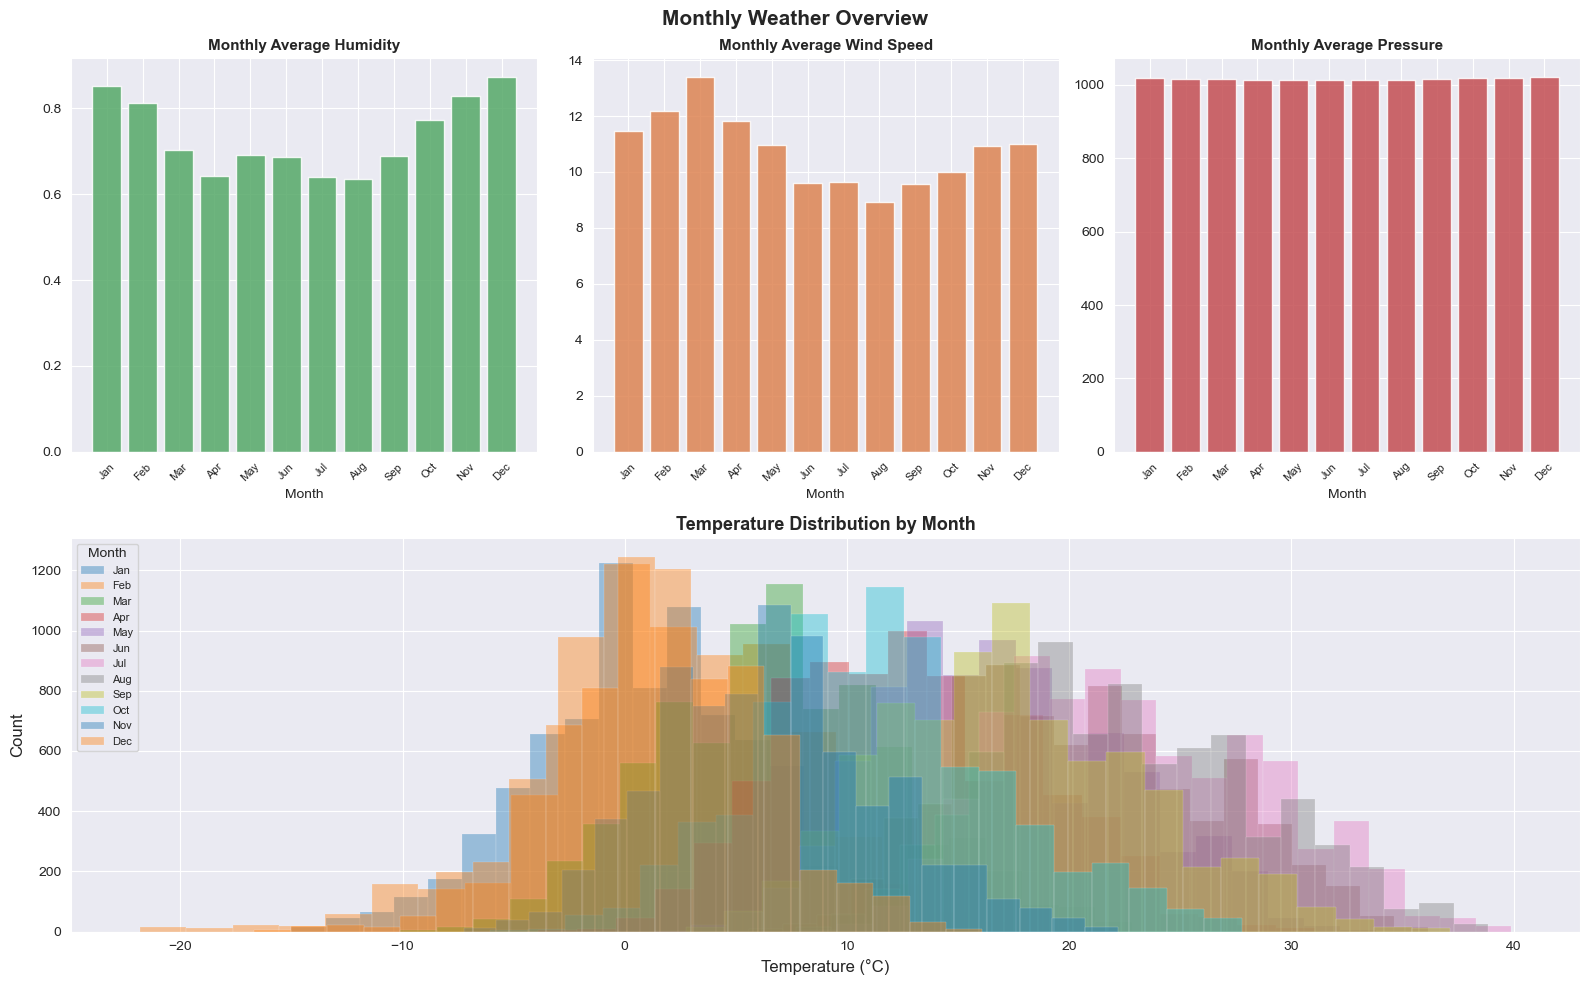

In [38]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_stats = df.groupby('Month')[['Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)']].mean().reset_index()
monthly_temp = df.groupby('Month')['Temperature (C)'].agg(['mean', 'min', 'max']).reset_index()

fig = plt.figure(figsize=(16, 10))

cols_titles = [
    ('Humidity', 'Monthly Average Humidity', '#55A868'),
    ('Wind Speed (km/h)', 'Monthly Average Wind Speed', '#DD8452'),
    ('Pressure (millibars)', 'Monthly Average Pressure', '#C44E52'),
]

for i, (col, title, color) in enumerate(cols_titles):
    ax = fig.add_subplot(2, 3, i + 1)
    ax.bar(monthly_stats['Month'], monthly_stats[col], color=color, alpha=0.85, edgecolor='white')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(months, rotation=45, fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Month')

ax_hist = fig.add_subplot(2, 1, 2)

for month, label in zip(range(1, 13), months):
    subset = df[df['Month'] == month]['Temperature (C)']
    ax_hist.hist(subset, bins=20, alpha=0.4, label=label, edgecolor='white', linewidth=0.3)

ax_hist.set_xlabel('Temperature (°C)', fontsize=12)
ax_hist.set_ylabel('Count', fontsize=12)
ax_hist.set_title('Temperature Distribution by Month', fontsize=13, fontweight='bold')
ax_hist.legend(title='Month', loc='upper left', fontsize=8)

plt.suptitle('Monthly Weather Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('./visuals/fig8_combined_monthly.png', bbox_inches='tight')
plt.show()

### 7.2 Hourly Temperature Pattern

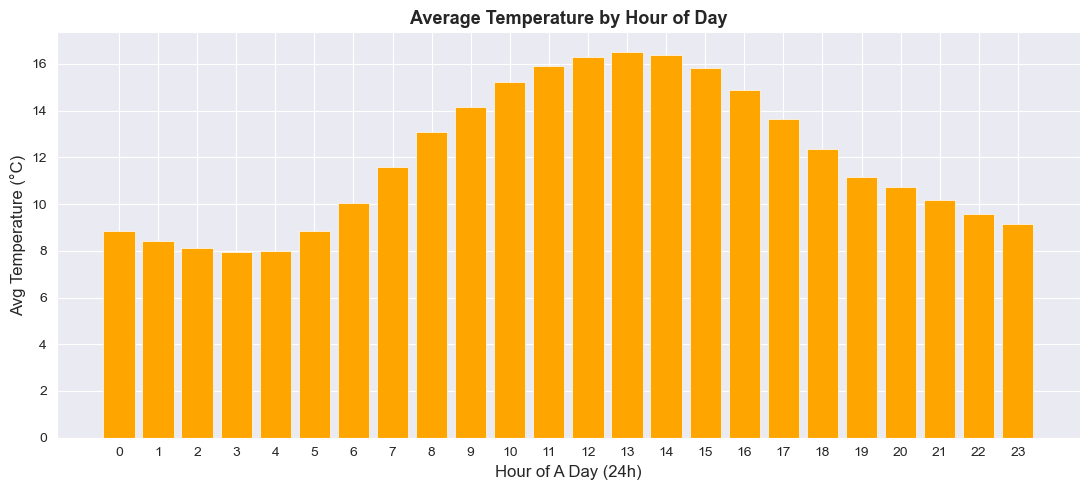

In [44]:
hourly_temp = df.groupby('Hour')['Temperature (C)'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(hourly_temp['Hour'], hourly_temp['Temperature (C)'],
       color='orange', edgecolor='white', linewidth=0.5)
ax.set_xticks(range(0, 24))
ax.set_xlabel('Hour of A Day (24h)', fontsize=12)
ax.set_ylabel('Avg Temperature (°C)', fontsize=12)
ax.set_title('Average Temperature by Hour of Day', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./visuals/fig9_hourly_temp.png', bbox_inches='tight')
plt.show()

## 8. Key Statistical Findings

In [98]:
print('=' * 55)
print('          KEY STATISTICAL FINDINGS SUMMARY')
print('=' * 55)

print(f"\nDataset Size    : {len(df):,} hourly records")
print(f"Date Range      : {df['Datetime'].min().date()} → {df['Datetime'].max().date()}")
print(f"Years Covered   : {df['Year'].nunique()} years")

print("\n--- Temperature (°C) ---")
print(f"  Mean  : {df['Temperature (C)'].mean():.2f}")
print(f"  Std   : {df['Temperature (C)'].std():.2f}")
print(f"  Min   : {df['Temperature (C)'].min():.2f}")
print(f"  Max   : {df['Temperature (C)'].max():.2f}")

print("\n--- Humidity ---")
print(f"  Mean  : {df['Humidity'].mean():.4f}")
print(f"  Std   : {df['Humidity'].std():.4f}")

print("\n--- Wind Speed (km/h) ---")
print(f"  Mean  : {df['Wind Speed (km/h)'].mean():.2f}")
print(f"  Max   : {df['Wind Speed (km/h)'].max():.2f}")

print("\n--- Precipitation Type Distribution ---")
print(df['Precip Type'].value_counts())

print("\n--- Top Correlation Pairs ---")
corr_matrix = df[num_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top3 = upper.stack().sort_values(ascending=False).head(3)
print(top3.to_string())
print('=' * 55)

          KEY STATISTICAL FINDINGS SUMMARY

Dataset Size    : 95,165 hourly records
Date Range      : 2005-12-31 → 2016-12-31
Years Covered   : 12 years

--- Temperature (°C) ---
  Mean  : 11.95
  Std   : 9.55
  Min   : -21.82
  Max   : 39.91

--- Humidity ---
  Mean  : 0.7350
  Std   : 0.1956

--- Wind Speed (km/h) ---
  Mean  : 10.78
  Max   : 63.85

--- Precipitation Type Distribution ---
Precip Type
rain    84116
snow    10532
none      517
Name: count, dtype: int64

--- Top Correlation Pairs ---
Temperature (C)           Apparent Temperature (C)    0.992651
                          Humidity                    0.632776
Apparent Temperature (C)  Humidity                    0.603435
